# Plant Pathology 2021 — Clean ResNet-50 Pipeline

This notebook is the complete training and evaluation workflow. It preserves the verified held-out results from the completed run and improves checkpoint recovery and inference organization.

**Use this notebook only when you need to train, resume training, retune thresholds, or reproduce evaluation.** For ordinary leaf prediction, use `Plant_Pathology_Predictor_No_Drive.ipynb`; it requires only the saved `.pt` checkpoint and a leaf photograph.

## 1. Setup and reproducibility

In [ ]:
!pip -q install iterative-stratification

from google.colab import drive
drive.mount("/content/gdrive")

import os, json, random, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, precision_score, recall_score, classification_report,
    multilabel_confusion_matrix, average_precision_score, roc_auc_score,
    precision_recall_curve
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/gdrive
Device: cpu


## 2. Paths and dataset extraction

Change `DRIVE_ZIP` only if your ZIP is stored elsewhere. Model artifacts are written to Google Drive so they survive a Colab restart.

In [ ]:
DRIVE_ZIP = Path("/content/gdrive/MyDrive/plant_project/plant-pathology-2021-fgvc8.zip")
LOCAL_DATA = Path("/content/plant_data")
TRAIN_DIR = LOCAL_DATA / "train_images"
CSV_PATH = LOCAL_DATA / "train.csv"
ARTIFACT_DIR = Path("/content/gdrive/MyDrive/plant_project/resnet50_complete")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = ARTIFACT_DIR / "best_resnet50.pt"
FINAL_MODEL_PATH = ARTIFACT_DIR / "plant_pathology_resnet50_complete.pt"
METRICS_PATH = ARTIFACT_DIR / "test_metrics.json"

if not (TRAIN_DIR.exists() and CSV_PATH.exists()):
    if not DRIVE_ZIP.exists():
        raise FileNotFoundError(f"Dataset ZIP not found: {DRIVE_ZIP}")
    print("Extracting dataset...")
    shutil.unpack_archive(str(DRIVE_ZIP), str(LOCAL_DATA))
else:
    print("Dataset already extracted.")

assert CSV_PATH.exists(), f"Missing {CSV_PATH}"
assert TRAIN_DIR.exists(), f"Missing {TRAIN_DIR}"
print("Images:", len(list(TRAIN_DIR.glob("*.jpg"))))

Extracting dataset...
Images: 18632


## 3. Load and validate labels

In [ ]:
CLASSES = [
    "complex", "frog_eye_leaf_spot", "healthy",
    "powdery_mildew", "rust", "scab"
]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASSES)}

df = pd.read_csv(CSV_PATH)
required_columns = {"image", "labels"}
if not required_columns.issubset(df.columns):
    raise ValueError(f"CSV must contain {required_columns}; got {df.columns.tolist()}")

missing_images = df.loc[~df["image"].map(lambda x: (TRAIN_DIR / x).exists()), "image"]
if len(missing_images):
    raise FileNotFoundError(f"{len(missing_images)} CSV images are missing; first: {missing_images.iloc[0]}")

observed_classes = sorted({x for labels in df["labels"] for x in labels.split()})
if observed_classes != sorted(CLASSES):
    raise ValueError(f"Unexpected labels: {observed_classes}")

def encode_labels(text):
    target = np.zeros(len(CLASSES), dtype=np.float32)
    for label in text.split():
        target[CLASS_TO_IDX[label]] = 1.0
    return target

df["target"] = df["labels"].map(encode_labels)
Y = np.stack(df["target"].to_numpy())
df.head()

,image,labels,target
0,800113bb65efe69e.jpg,healthy,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"
1,8002cb321f8bfcdf.jpg,scab frog_eye_leaf_spot complex,"[1.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
2,80070f7fb5e2ccaa.jpg,scab,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
3,80077517781fb94f.jpg,scab,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
4,800cbf0ff87721f8.jpg,complex,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


## 4. Exploratory data analysis

Rows: 18,632
Duplicates by filename: 0
Missing values:


,count
image,0
labels,0


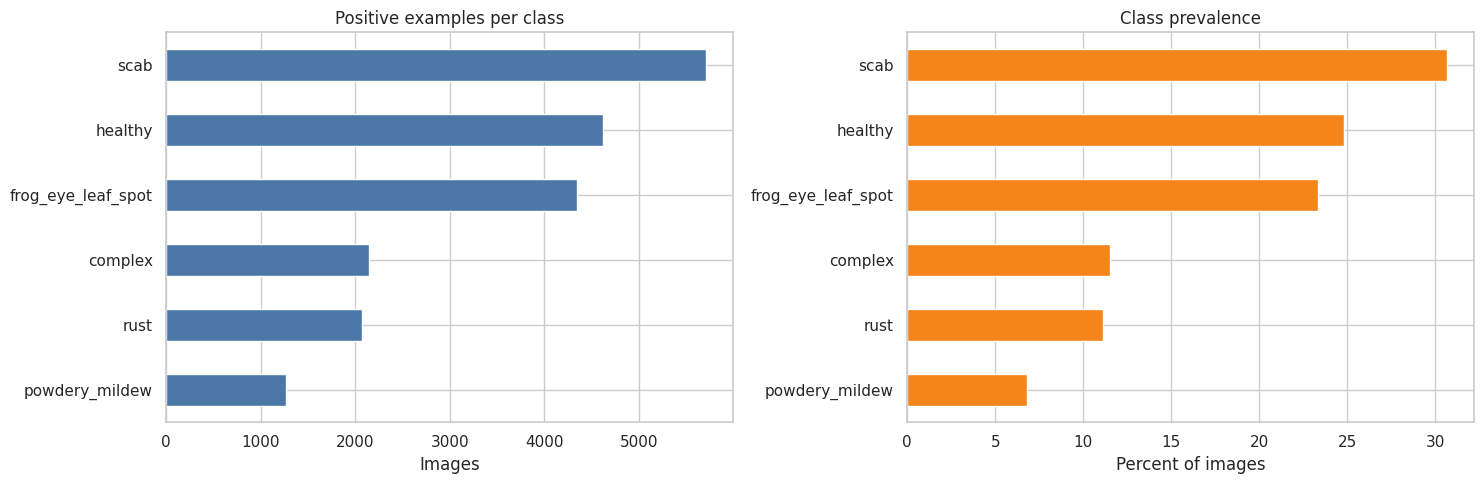

,count,percent
powdery_mildew,1271,6.82
rust,2077,11.15
complex,2151,11.54
frog_eye_leaf_spot,4352,23.36
healthy,4624,24.82
scab,5712,30.66


In [ ]:
print(f"Rows: {len(df):,}")
print("Duplicates by filename:", df["image"].duplicated().sum())
print("Missing values:")
display(df[["image", "labels"]].isna().sum().to_frame("count"))

label_counts = pd.Series(Y.sum(axis=0).astype(int), index=CLASSES).sort_values()
label_rates = label_counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
label_counts.plot.barh(ax=axes[0], color="#4C78A8")
axes[0].set(title="Positive examples per class", xlabel="Images")
label_rates.plot.barh(ax=axes[1], color="#F58518")
axes[1].set(title="Class prevalence", xlabel="Percent of images")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": label_counts, "percent": label_rates.round(2)}))

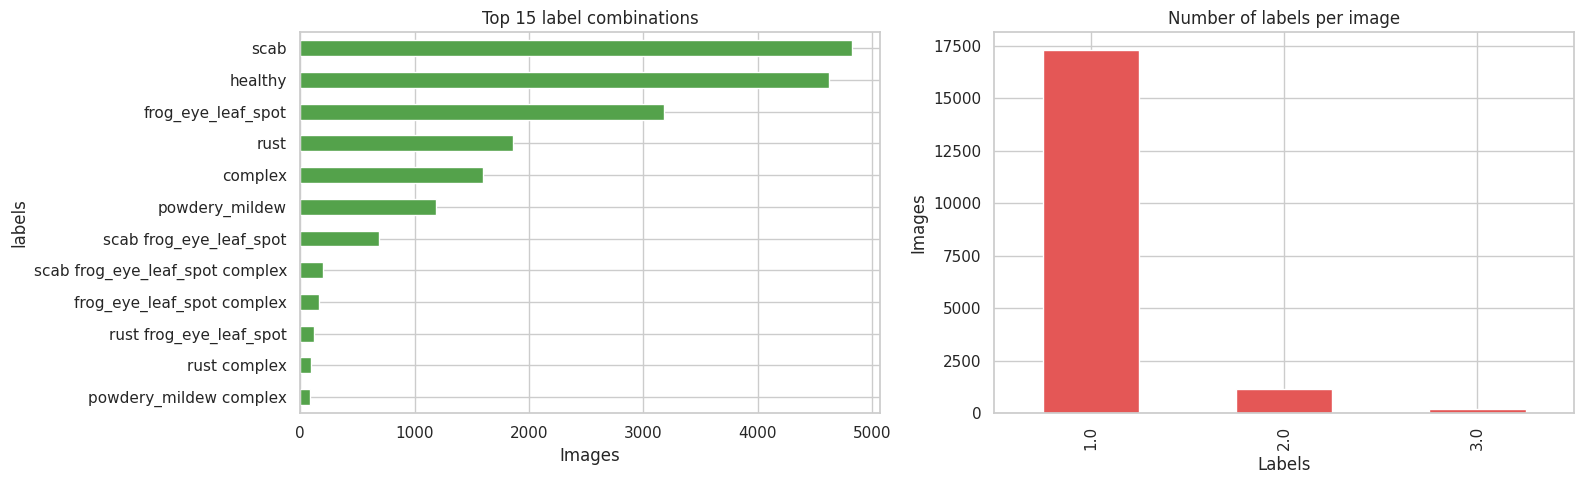

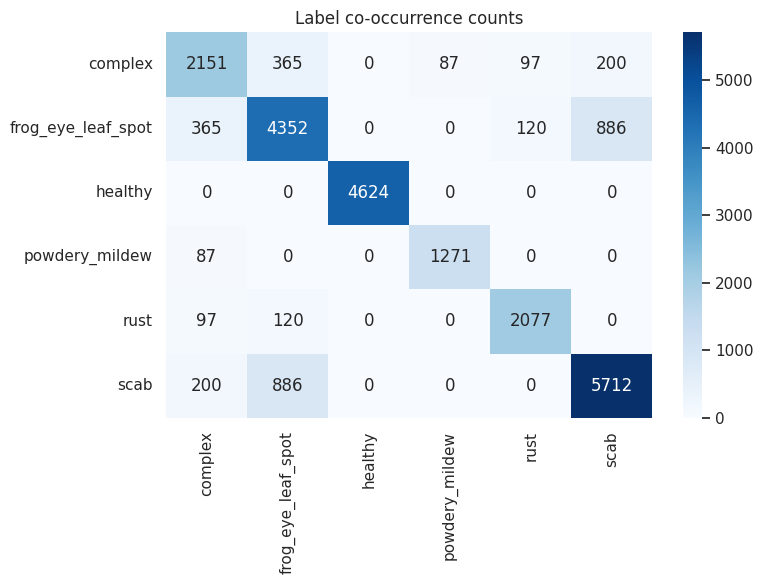

In [ ]:
combos = df["labels"].value_counts().head(15)
label_cardinality = Y.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
combos.sort_values().plot.barh(ax=axes[0], color="#54A24B")
axes[0].set(title="Top 15 label combinations", xlabel="Images")
pd.Series(label_cardinality).value_counts().sort_index().plot.bar(ax=axes[1], color="#E45756")
axes[1].set(title="Number of labels per image", xlabel="Labels", ylabel="Images")
plt.tight_layout()
plt.show()

cooccurrence = Y.T @ Y
plt.figure(figsize=(8, 6))
sns.heatmap(cooccurrence, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Label co-occurrence counts")
plt.tight_layout()
plt.show()

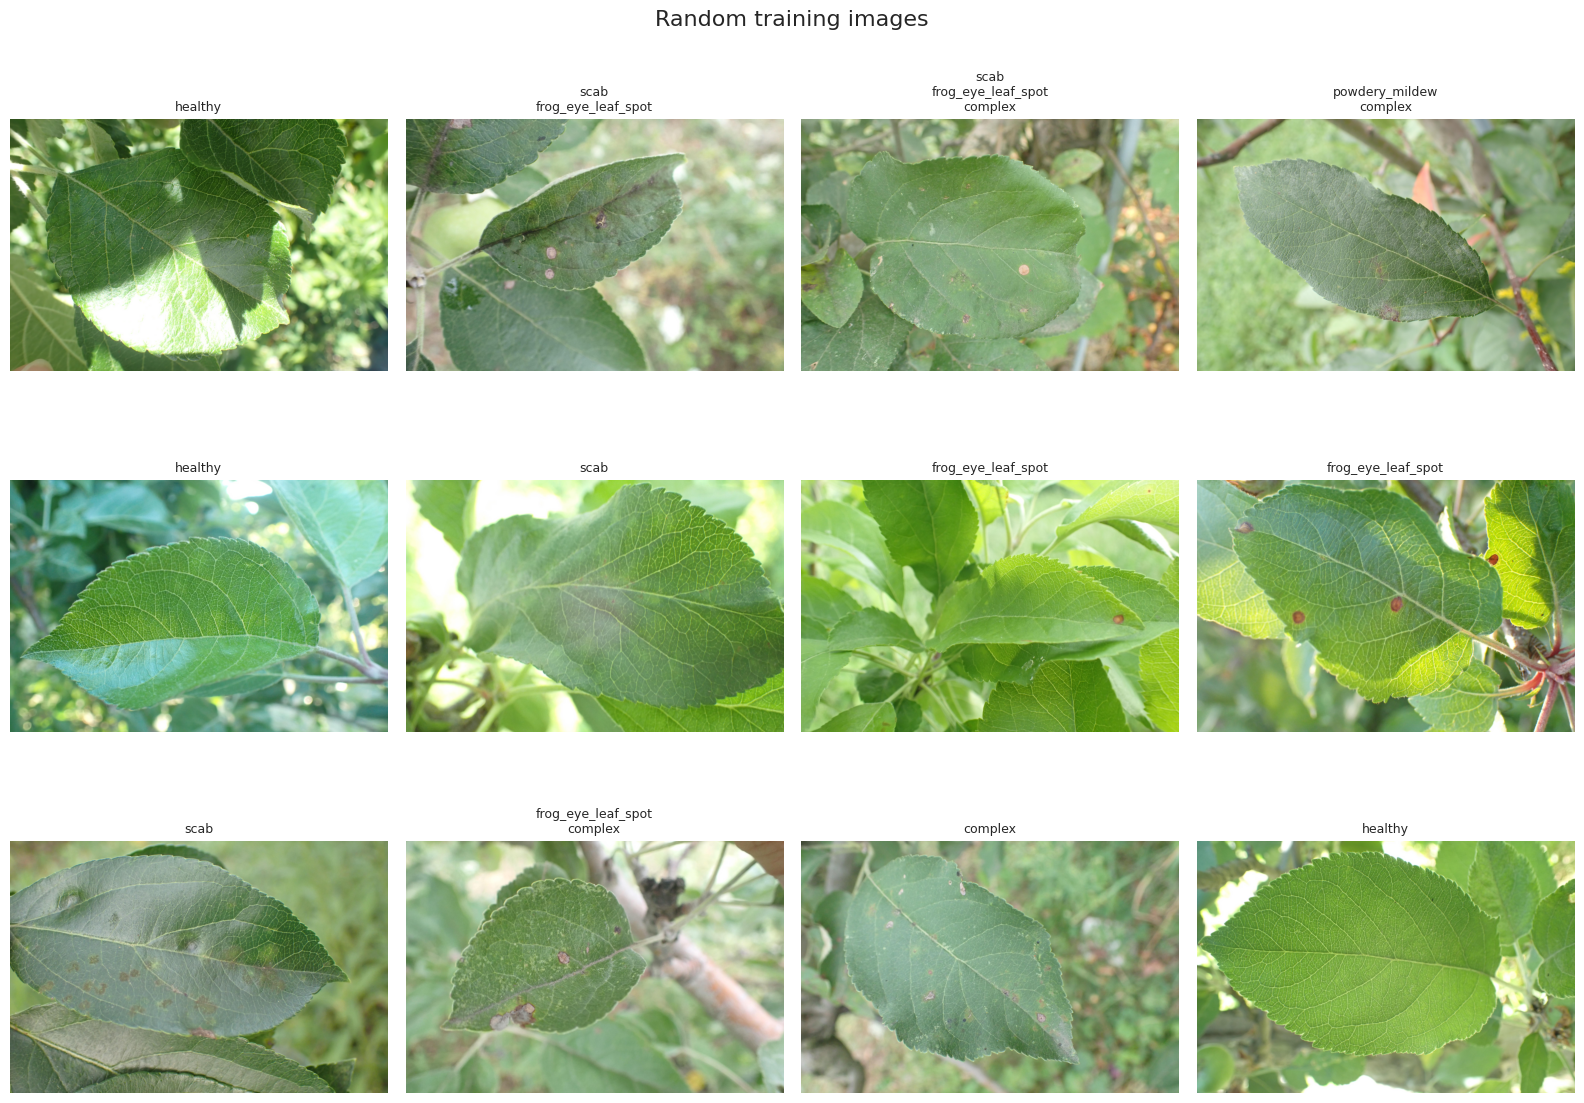

Sampled image width  (min/median/max): 2592 4000 5184
Sampled image height (min/median/max): 1728 2672 3456


In [ ]:
sample_rows = df.sample(12, random_state=SEED)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, (_, row) in zip(axes.ravel(), sample_rows.iterrows()):
    with Image.open(TRAIN_DIR / row["image"]) as im:
        ax.imshow(im.convert("RGB"))
    ax.set_title(row["labels"].replace(" ", "\n"), fontsize=9)
    ax.axis("off")
plt.suptitle("Random training images", fontsize=16)
plt.tight_layout()
plt.show()

dimension_rows = df.sample(min(500, len(df)), random_state=SEED)
dims = []
for name in dimension_rows["image"]:
    with Image.open(TRAIN_DIR / name) as im:
        dims.append(im.size)
dims = np.asarray(dims)
print("Sampled image width  (min/median/max):", dims[:,0].min(), int(np.median(dims[:,0])), dims[:,0].max())
print("Sampled image height (min/median/max):", dims[:,1].min(), int(np.median(dims[:,1])), dims[:,1].max())

## 5. Multilabel-stratified train/validation/test split

The split is 70% training, 15% validation, and 15% test. Multilabel stratification preserves the prevalence of all six labels much better than an ordinary random split.

Train / validation / test: 13063 2773 2796


,train,validation,test
complex,11.530000,11.610000,11.55
frog_eye_leaf_spot,23.320000,23.549999,23.35
healthy,24.780001,24.990000,24.82
powdery_mildew,6.810000,6.850000,6.83
rust,11.130000,11.220000,11.16
scab,30.610001,30.910000,30.65


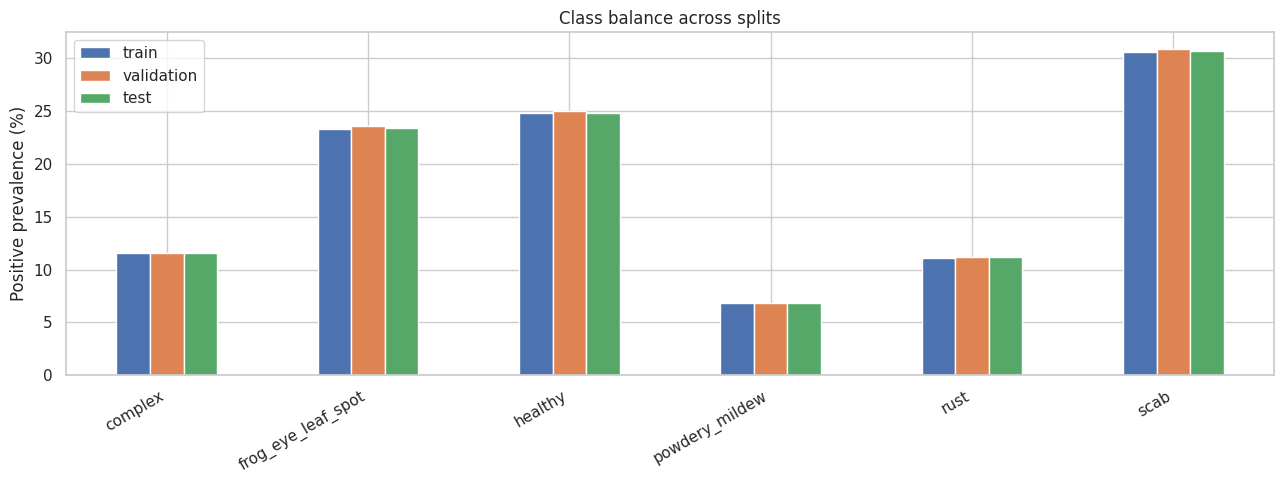

In [ ]:
splitter_1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(splitter_1.split(np.zeros(len(df)), Y))

temp_Y = Y[temp_idx]
splitter_2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(splitter_2.split(np.zeros(len(temp_idx)), temp_Y))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[temp_idx[val_rel_idx]].reset_index(drop=True)
test_df = df.iloc[temp_idx[test_rel_idx]].reset_index(drop=True)

print("Train / validation / test:", len(train_df), len(val_df), len(test_df))

split_rates = pd.DataFrame({
    "train": np.stack(train_df.target).mean(axis=0),
    "validation": np.stack(val_df.target).mean(axis=0),
    "test": np.stack(test_df.target).mean(axis=0),
}, index=CLASSES) * 100
display(split_rates.round(2))
split_rates.plot.bar(figsize=(13, 5))
plt.ylabel("Positive prevalence (%)")
plt.title("Class balance across splits")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6. Preprocessing and data loaders

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.70, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomApply([transforms.ColorJitter(0.2, 0.2, 0.2, 0.05)], p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.10)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class PlantDataset(Dataset):
    def __init__(self, frame, image_dir, transform):
        self.frame = frame.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        with Image.open(self.image_dir / row["image"]) as im:
            image = im.convert("RGB")
        image = self.transform(image)
        target = torch.tensor(row["target"], dtype=torch.float32)
        return image, target

train_dataset = PlantDataset(train_df, TRAIN_DIR, train_transform)
val_dataset = PlantDataset(val_df, TRAIN_DIR, eval_transform)
test_dataset = PlantDataset(test_df, TRAIN_DIR, eval_transform)

loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                     pin_memory=torch.cuda.is_available(), persistent_workers=NUM_WORKERS > 0)
train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

images, targets = next(iter(train_loader))
print("Batch:", images.shape, targets.shape)

Batch: torch.Size([32, 3, 224, 224]) torch.Size([32, 6])


## 7. ResNet-50 model and training configuration

The pretrained backbone uses a smaller learning rate than the new classifier. `BCEWithLogitsLoss` is the correct objective because an image may contain more than one disease.

In [ ]:
def build_resnet50(num_classes, dropout=0.35, pretrained=False):
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    network = models.resnet50(weights=weights)
    network.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(network.fc.in_features, num_classes),
    )
    return network


model = build_resnet50(
    num_classes=len(CLASSES),
    dropout=0.35,
    pretrained=True,
).to(device)

train_Y = np.stack(train_df["target"].to_numpy())
positive_counts = train_Y.sum(axis=0)
negative_counts = len(train_Y) - positive_counts
pos_weights = np.clip(
    negative_counts / np.maximum(positive_counts, 1),
    1.0,
    10.0,
)
pos_weight_tensor = torch.tensor(
    pos_weights,
    dtype=torch.float32,
    device=device,
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = torch.optim.AdamW([
    {
        "params": [p for name, p in model.named_parameters() if not name.startswith("fc.")],
        "lr": 3e-5,
    },
    {"params": model.fc.parameters(), "lr": 2e-4},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-7,
)

NUM_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 4

print(model.fc)
print("Positive weights:", dict(zip(CLASSES, pos_weights.round(2))))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 291MB/s]


Sequential(
  (0): Dropout(p=0.35, inplace=False)
  (1): Linear(in_features=2048, out_features=6, bias=True)
)
Positive weights: {'complex': np.float32(7.67), 'frog_eye_leaf_spot': np.float32(3.29), 'healthy': np.float32(3.04), 'powdery_mildew': np.float32(10.0), 'rust': np.float32(7.98), 'scab': np.float32(2.27)}


## 8. Train and save the best validation checkpoint

In [ ]:
def collect_predictions(model, loader):
    model.eval()
    all_targets, all_probabilities = [], []

    with torch.inference_mode():
        for images, targets in loader:
            images = images.to(device, non_blocking=True)
            probabilities = torch.sigmoid(model(images))
            all_targets.append(targets.numpy())
            all_probabilities.append(probabilities.cpu().numpy())

    return np.concatenate(all_targets), np.concatenate(all_probabilities)



In [ ]:

RESUME_TRAINING = False
ADDITIONAL_EPOCHS = NUM_EPOCHS

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
history = []
best_val_f1 = -np.inf
epochs_without_improvement = 0
start_epoch = 1

if RESUME_TRAINING and BEST_MODEL_PATH.exists():
    resume = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(resume["model_state_dict"])
    best_val_f1 = resume.get("best_val_f1_at_0.5", -np.inf)
    history = resume.get("history", [])
    start_epoch = resume.get("epoch", 0) + 1

    if "optimizer_state_dict" in resume:
        optimizer.load_state_dict(resume["optimizer_state_dict"])
    if "scheduler_state_dict" in resume:
        scheduler.load_state_dict(resume["scheduler_state_dict"])
    if "scaler_state_dict" in resume:
        scaler.load_state_dict(resume["scaler_state_dict"])

    print(f"Resuming at epoch {start_epoch}; best validation F1={best_val_f1:.4f}")


for epoch in range(start_epoch, start_epoch + ADDITIONAL_EPOCHS):
    model.train()
    train_loss = 0.0

    for images, targets in train_loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_dataset)
    y_val_epoch, val_probs_epoch = collect_predictions(model, val_loader)
    val_pred_epoch = (val_probs_epoch >= 0.5).astype(np.uint8)
    val_f1 = f1_score(
        y_val_epoch,
        val_pred_epoch,
        average="macro",
        zero_division=0,
    )
    val_ap = average_precision_score(
        y_val_epoch,
        val_probs_epoch,
        average="macro",
    )
    scheduler.step(val_f1)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_macro_f1_at_0.5": val_f1,
        "val_macro_ap": val_ap,
    })
    print(
        f"Epoch {epoch:02d} | loss {train_loss:.4f} | "
        f"val F1 {val_f1:.4f} | val AP {val_ap:.4f}"
    )

    if val_f1 > best_val_f1 + 1e-4:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "history": history,
            "architecture": "resnet50",
            "classes": CLASSES,
            "image_size": IMAGE_SIZE,
            "dropout": 0.35,
            "best_val_f1_at_0.5": float(best_val_f1),
            "seed": SEED,
        }, BEST_MODEL_PATH)
        print("  Saved new best checkpoint")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break


history_df = pd.DataFrame(history)
display(history_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
history_df.plot(x="epoch", y="train_loss", marker="o", ax=axes[0], title="Training loss")
history_df.plot(
    x="epoch",
    y=["val_macro_f1_at_0.5", "val_macro_ap"],
    marker="o",
    ax=axes[1],
    title="Validation metrics",
)
plt.tight_layout()
plt.show()

## 9. Reload the best weights, then tune thresholds on validation only

This ordering is essential: thresholds must be tuned for the same weights that will be evaluated and deployed.

In [ ]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device).eval()

print(
    "Reloaded best validation model:",
    checkpoint["best_val_f1_at_0.5"],
)

y_val, val_probs = collect_predictions(model, val_loader)
candidate_thresholds = np.arange(0.05, 0.951, 0.01)
thresholds = np.full(len(CLASSES), 0.5, dtype=np.float32)

for class_index, class_name in enumerate(CLASSES):
    scores = np.asarray([
        f1_score(
            y_val[:, class_index],
            val_probs[:, class_index] >= threshold,
            zero_division=0,
        )
        for threshold in candidate_thresholds
    ])

    best_index = int(scores.argmax())
    thresholds[class_index] = candidate_thresholds[best_index]
    print(
        f"{class_name:22s} threshold={thresholds[class_index]:.2f} "
        f"validation F1={scores[best_index]:.4f}"
    )

val_predictions = (val_probs >= thresholds).astype(np.uint8)
tuned_val_f1 = f1_score(
    y_val,
    val_predictions,
    average="macro",
    zero_division=0,
)
print(f"\nTuned validation macro F1: {tuned_val_f1:.4f}")

Reloaded best validation model: 0.8826067908077064
complex                threshold=0.77 validation F1=0.7465
frog_eye_leaf_spot     threshold=0.57 validation F1=0.8780
healthy                threshold=0.43 validation F1=0.9806
powdery_mildew         threshold=0.69 validation F1=0.9499
rust                   threshold=0.73 validation F1=0.9252
scab                   threshold=0.72 validation F1=0.9008

Tuned validation macro F1: 0.8968


## 10. Final held-out test evaluation

Do not use these results to choose thresholds or alter training. If you make additional model decisions, retrain and reserve a new untouched test set.

In [ ]:
y_test, test_probs = collect_predictions(model, test_loader)
test_predictions = (test_probs >= thresholds).astype(np.uint8)

metrics = {
    "macro_f1": float(f1_score(y_test, test_predictions, average="macro", zero_division=0)),
    "micro_f1": float(f1_score(y_test, test_predictions, average="micro", zero_division=0)),
    "macro_precision": float(precision_score(y_test, test_predictions, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(y_test, test_predictions, average="macro", zero_division=0)),
    "macro_average_precision": float(average_precision_score(y_test, test_probs, average="macro")),
}
try:
    metrics["macro_roc_auc"] = float(roc_auc_score(y_test, test_probs, average="macro"))
except ValueError:
    metrics["macro_roc_auc"] = None

display(pd.Series(metrics, name="held-out test"))
print(classification_report(y_test, test_predictions, target_names=CLASSES, zero_division=0))

with open(METRICS_PATH, "w") as f:
    json.dump({"metrics": metrics, "thresholds": dict(zip(CLASSES, thresholds.tolist()))}, f, indent=2)
print("Saved metrics:", METRICS_PATH)

,held-out test
macro_f1,0.893355
micro_f1,0.898522
macro_precision,0.876505
macro_recall,0.912996
macro_average_precision,0.946804
macro_roc_auc,0.986984


                    precision    recall  f1-score   support

           complex       0.67      0.80      0.73       323
frog_eye_leaf_spot       0.84      0.90      0.87       653
           healthy       0.97      0.98      0.97       694
    powdery_mildew       0.95      0.96      0.95       191
              rust       0.91      0.95      0.93       312
              scab       0.93      0.89      0.91       857

         micro avg       0.88      0.91      0.90      3030
         macro avg       0.88      0.91      0.89      3030
      weighted avg       0.89      0.91      0.90      3030
       samples avg       0.92      0.94      0.92      3030

Saved metrics: /content/gdrive/MyDrive/plant_project/resnet50_complete/test_metrics.json


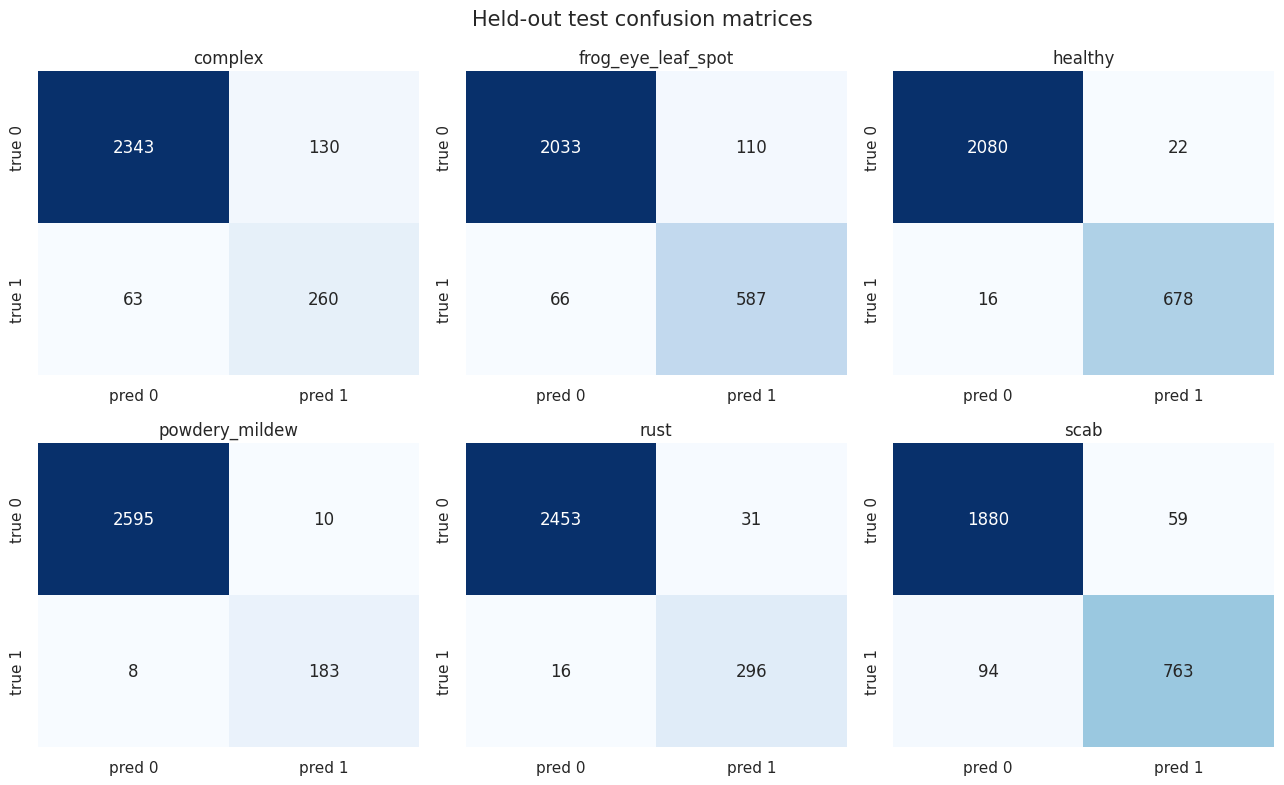

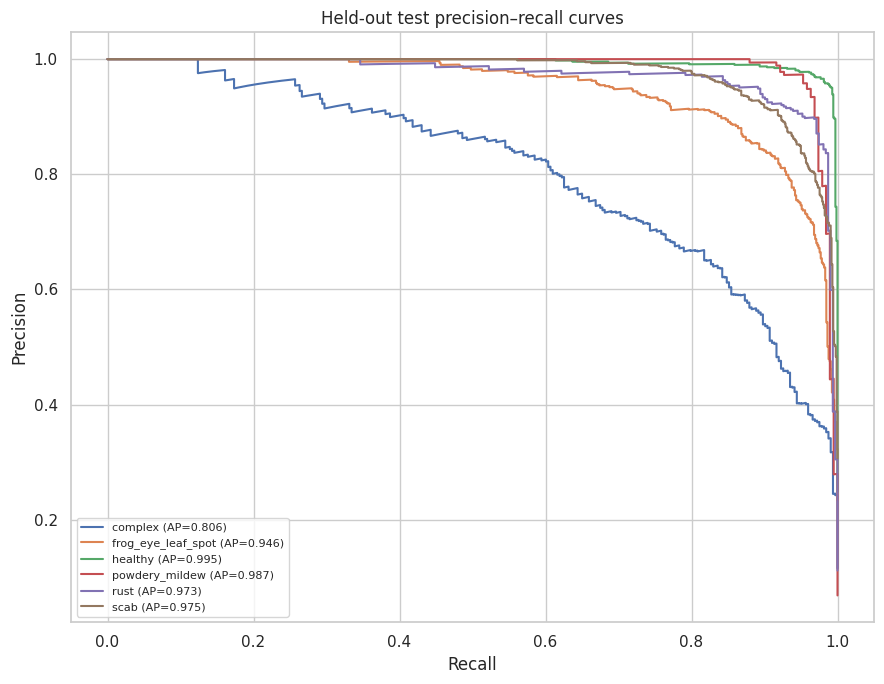

In [ ]:
confusion = multilabel_confusion_matrix(y_test, test_predictions)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, class_name, matrix in zip(axes.ravel(), CLASSES, confusion):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
    ax.set_title(class_name)
plt.suptitle("Held-out test confusion matrices", fontsize=15)
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 7))
for i, class_name in enumerate(CLASSES):
    precision, recall, _ = precision_recall_curve(y_test[:, i], test_probs[:, i])
    ap = average_precision_score(y_test[:, i], test_probs[:, i])
    plt.plot(recall, precision, label=f"{class_name} (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Held-out test precision–recall curves")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 11. Save a self-contained inference checkpoint

In [ ]:
# Reload the best ResNet-50 checkpoint before creating
# the complete inference checkpoint

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()


# Make sure threshold tuning and test evaluation were run
if "thresholds" not in globals():
    raise RuntimeError(
        "Thresholds are missing. Run Section 9 first."
    )

if "metrics" not in globals():
    raise RuntimeError(
        "Test metrics are missing. Run Section 10 first."
    )


final_checkpoint = {
    **checkpoint,

    # Ensure the saved weights are the best restored weights
    "model_state_dict": model.state_dict(),

    "architecture": "resnet50",
    "classes": CLASSES,
    "image_size": IMAGE_SIZE,
    "dropout": 0.35,

    "thresholds": thresholds.tolist(),

    "preprocessing": {
        "resize": 256,
        "center_crop": IMAGE_SIZE,
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225]
    },

    "test_metrics": metrics
}


torch.save(
    final_checkpoint,
    FINAL_MODEL_PATH
)

print(
    "Complete ResNet-50 checkpoint saved to:",
    FINAL_MODEL_PATH
)

Complete ResNet-50 checkpoint saved to: /content/gdrive/MyDrive/plant_project/resnet50_complete/plant_pathology_resnet50_complete.pt


## 12. Human-readable single-image inference

The function loads no training data and returns probabilities plus threshold decisions. Because `healthy` should be mutually exclusive with disease labels, a simultaneous healthy+disease result is reported as uncertain rather than silently hidden.

True label: frog_eye_leaf_spot


,class,probability,threshold,predicted
0,frog_eye_leaf_spot,99.38%,0.57,True
1,complex,10.91%,0.77,False
2,scab,1.57%,0.72,False
3,rust,0.09%,0.73,False
4,powdery_mildew,0.03%,0.69,False
5,healthy,0.03%,0.43,False


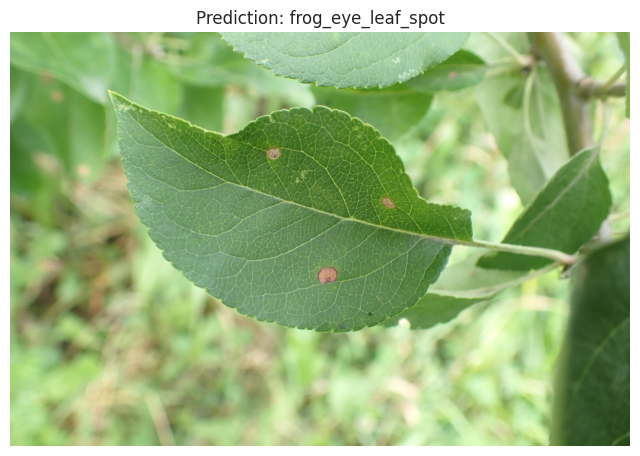

In [ ]:
def build_inference_transform(saved):
    config = saved.get("preprocessing", {})
    return transforms.Compose([
        transforms.Resize(config.get("resize", 256)),
        transforms.CenterCrop(config.get("center_crop", saved.get("image_size", 224))),
        transforms.ToTensor(),
        transforms.Normalize(
            config.get("mean", [0.485, 0.456, 0.406]),
            config.get("std", [0.229, 0.224, 0.225]),
        ),
    ])


saved_mode  l = torch.load(FINAL_MODEL_PATH, map_location=device)
inference_classes = saved_model["classes"]
inference_thresholds = np.asarray(saved_model["thresholds"], dtype=np.float32)
inference_transform = build_inference_transform(saved_model)

inference_model = build_resnet50(
    num_classes=len(inference_classes),
    dropout=saved_model.get("dropout", 0.35),
    pretrained=False,
).to(device)
inference_model.load_state_dict(saved_model["model_state_dict"])
inference_model.eval()


def predict_leaf(image_path, show=True):
    image_path = Path(image_path)
    with Image.open(image_path) as source:
        image = source.convert("RGB")

    tensor = inference_transform(image).unsqueeze(0).to(device)
    with torch.inference_mode():
        probabilities = torch.sigmoid(inference_model(tensor)).squeeze(0).cpu().numpy()

    decisions = probabilities >= inference_thresholds
    results = pd.DataFrame({
        "class": inference_classes,
        "probability": probabilities,
        "threshold": inference_thresholds,
        "predicted": decisions,
    }).sort_values("probability", ascending=False).reset_index(drop=True)

    predicted_labels = results.loc[results["predicted"], "class"].tolist()
    has_conflict = "healthy" in predicted_labels and len(predicted_labels) > 1
    if has_conflict:
        summary = "uncertain: healthy and disease signals conflict"
    elif predicted_labels:
        summary = ", ".join(predicted_labels)
    else:
        summary = "uncertain: no class exceeded its threshold"

    if show:
        display(results.style.format({"probability": "{:.2%}", "threshold": "{:.2f}"}))
        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Prediction: {summary}")
        plt.show()

    return {"prediction": summary, "probabilities": results}


sample = test_df.sample(1, random_state=7).iloc[0]
print("True label:", sample["labels"])
prediction = predict_leaf(TRAIN_DIR / sample["image"])